In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [11]:
traffic = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


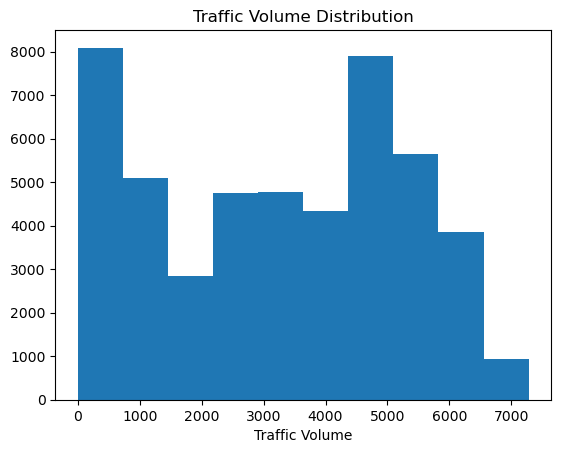

In [12]:
plt.hist(traffic["traffic_volume"])
plt.xlabel("Traffic Volume")
plt.title("Traffic Volume Distribution")

plt.show()

In [13]:
traffic['date_time'] = pd.to_datetime(traffic['date_time'])

day = traffic.copy()[(traffic['date_time'].dt.hour >= 7) | (traffic['date_time'].dt.hour < 19)]

night = traffic.copy()[(traffic['date_time'].dt.hour >= 19) | (traffic['date_time'].dt.hour < 7)]


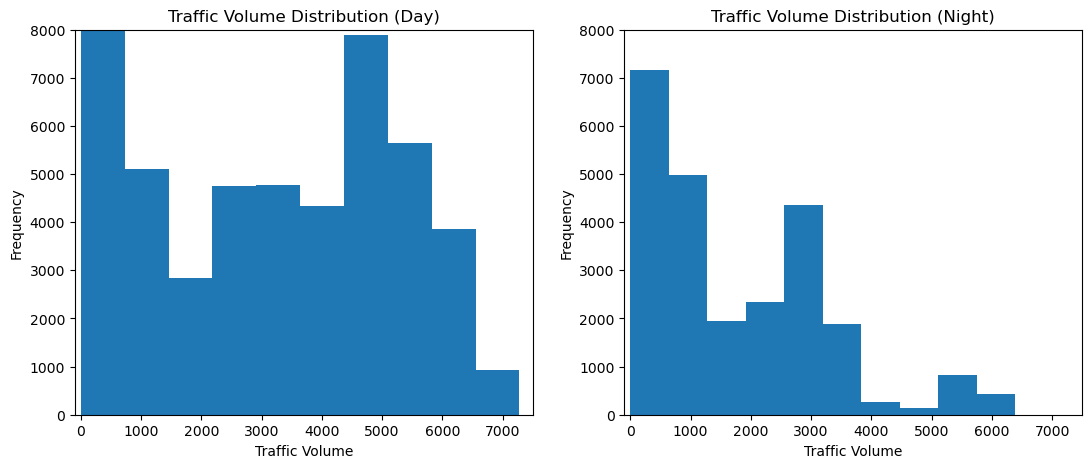

In [ ]:
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.hist(day["traffic_volume"])
plt.xlim(-100,7500)
plt.ylim(0,8000)
plt.title("Traffic Volume Distribution (Day)")
plt.ylabel("Frequency")
plt.xlabel("Traffic Volume")

plt.subplot(1,2,2)
plt.hist(night["traffic_volume"])
plt.xlim(-100,7500)
plt.ylim(0,8000)
plt.title("Traffic Volume Distribution (Night)")
plt.ylabel("Frequency")
plt.xlabel("Traffic Volume")

plt.show()

In [17]:
day.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,2016-01-05 10:46:16.773711616,3259.818355
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 11:45:00,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-11 03:30:00,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000
std,13.338232,44.789133,0.008168,39.015750,NaN,1986.860670


In [18]:
night.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume
count,24327.000000,24327.000000,24327.000000,24327.000000,24327,24327.000000
mean,280.173600,0.139145,0.000192,45.672011,2016-01-05 20:26:34.672585984,1785.377441
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 19:00:00,0.000000
25%,271.700000,0.000000,0.000000,1.000000,2014-02-08 20:30:00,530.000000
50%,281.379000,0.000000,0.000000,40.000000,2016-06-09 23:00:00,1287.000000
75%,290.700000,0.000000,0.000000,90.000000,2017-08-08 20:30:00,2819.000000
max,307.680000,55.630000,0.510000,100.000000,2018-09-30 23:00:00,6386.000000
std,13.296357,1.110872,0.007434,40.048382,NaN,1441.951197


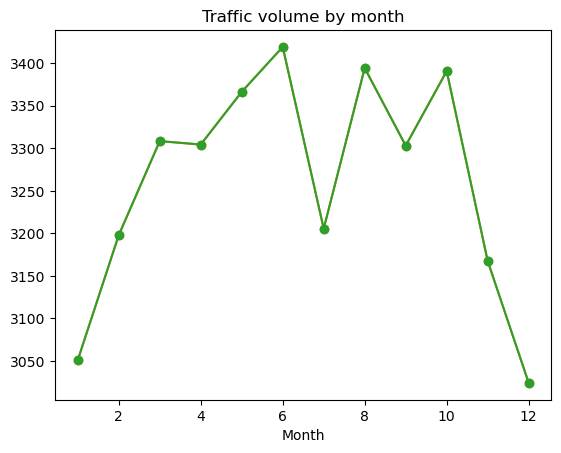

In [22]:
day["month"] = day["date_time"].dt.month
by_month = day.groupby("month").mean(numeric_only=True)
plt.plot(by_month['traffic_volume'], marker = 'o')
plt.title("Traffic volume by month")
plt.xlabel("Month")
plt.show()

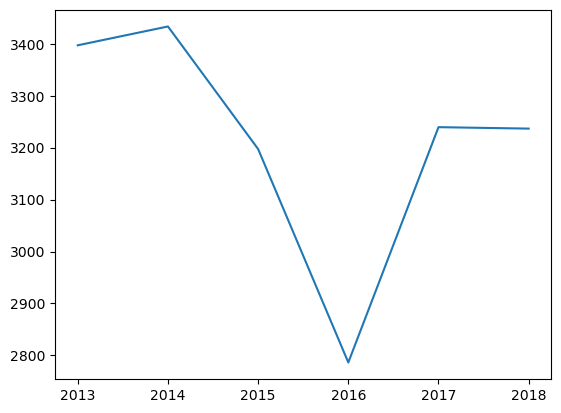

In [23]:
day["year"] = day["date_time"].dt.year
only_july = day[day["month"] == 7]
plt.plot(only_july.groupby("year").mean(numeric_only=True)["traffic_volume"])
plt.show()

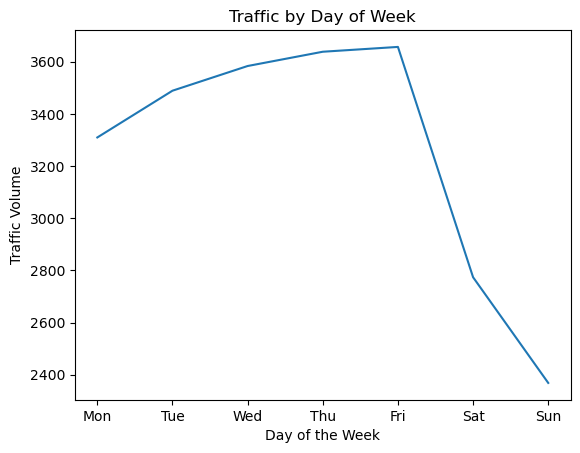

In [25]:
day["dayofweek"] = day["date_time"].dt.dayofweek
by_dayofweek = day.groupby("dayofweek").mean(numeric_only=True)
plt.plot(by_dayofweek["traffic_volume"])

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.xticks(range(len(days)), days)
plt.xlabel("Day of the Week")
plt.ylabel("Traffic Volume")
plt.title("Traffic by Day of Week")

plt.show()

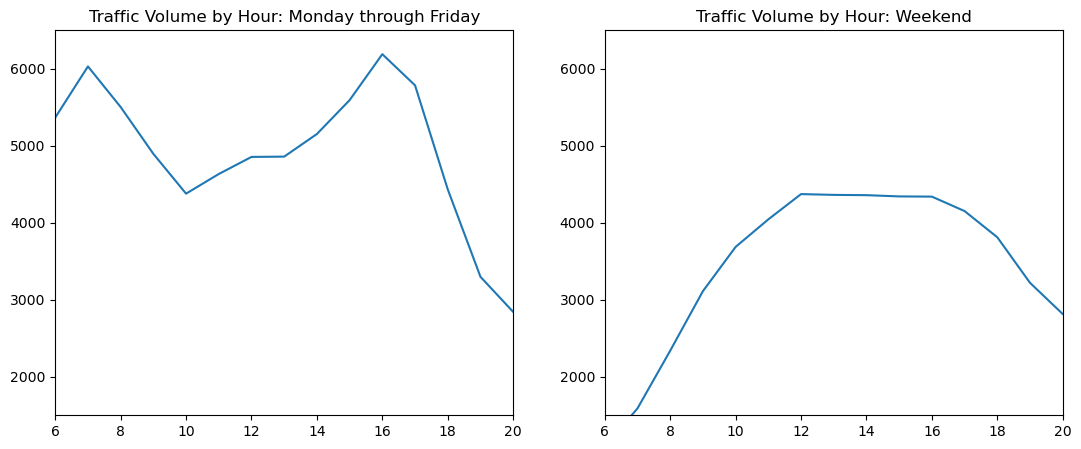

In [30]:
day["hour"] = day["date_time"].dt.hour
business_days = day.copy()[day["dayofweek"] <= 4] # 4 == Friday
weekend = day.copy()[day["dayofweek"] >= 5] # 4 == Saturday
by_hour_business = business_days.groupby("hour").mean(numeric_only=True)
by_hour_weekend = weekend.groupby("hour").mean(numeric_only=True)

plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.plot(by_hour_business["traffic_volume"])
plt.xlim(6,20)
plt.ylim(1500,6500)
plt.title("Traffic Volume by Hour: Monday through Friday")

plt.subplot(1,2,2)
plt.plot(by_hour_weekend["traffic_volume"])
plt.xlim(6,20)
plt.ylim(1500,6500)
plt.title("Traffic Volume by Hour: Weekend")

plt.show()

In [32]:
weather_cols = ['clouds_all', 'snow_1h', 'temp', 'traffic_volume']
day[weather_cols].corr(numeric_only=True)["traffic_volume"].sort_values()

snow_1h           0.000733
clouds_all        0.067054
temp              0.130299
traffic_volume    1.000000
Name: traffic_volume, dtype: float64

<Figure size 1000x600 with 0 Axes>

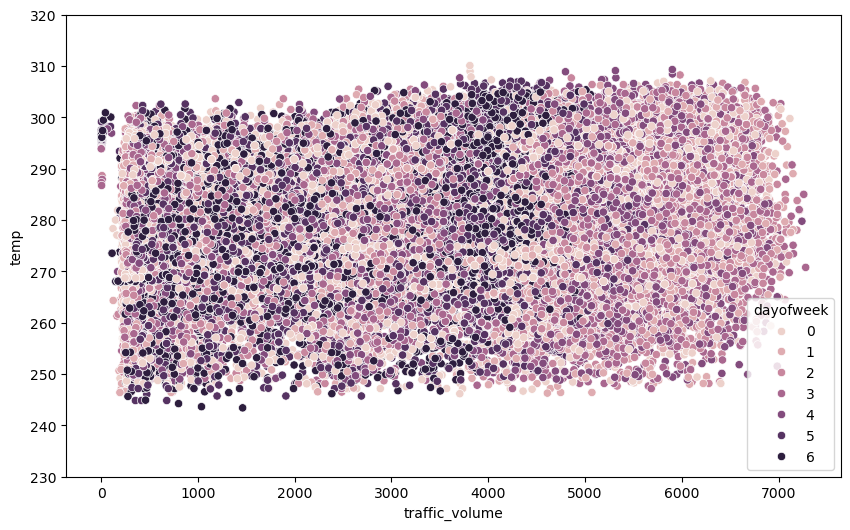

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="traffic_volume", y="temp", hue = "dayofweek", data=day)
plt.ylim(230, 320)
plt.show()

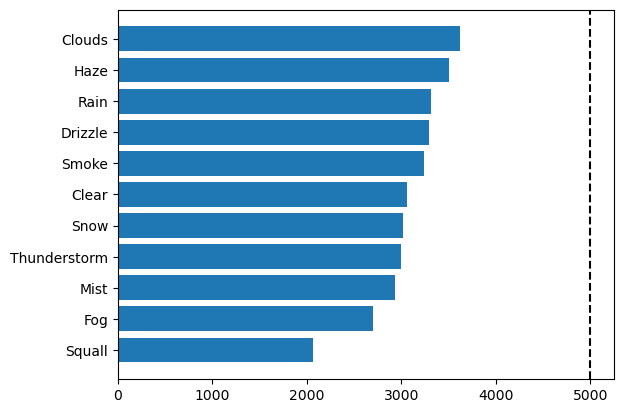

In [41]:
by_weather_main = day.groupby("weather_main").mean(numeric_only=True).sort_values("traffic_volume")
plt.barh(by_weather_main.index, by_weather_main["traffic_volume"])
plt.axvline(x=5000,linestyle="--",color="k")
plt.show()

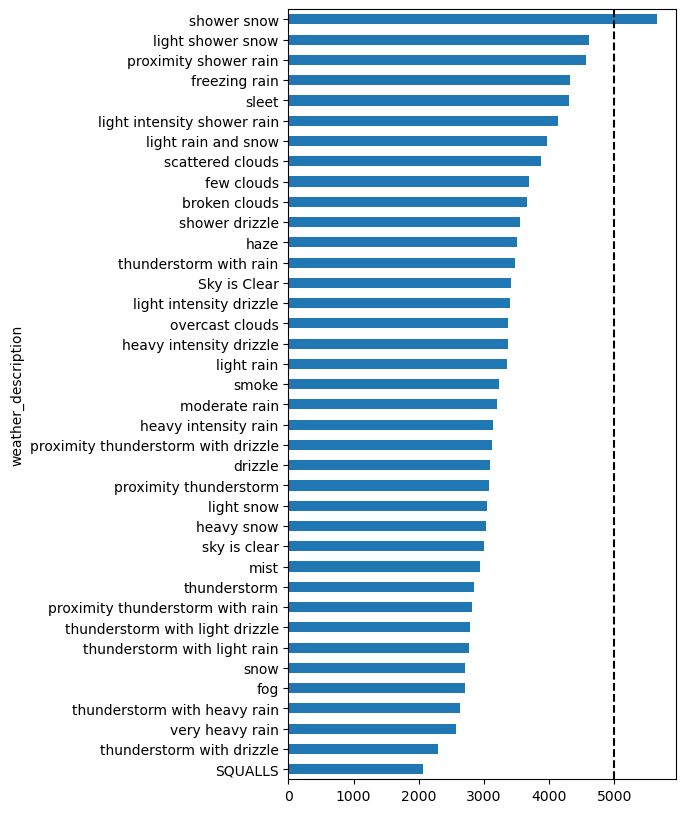

In [42]:
by_weather_description = day.groupby("weather_description").mean(numeric_only=True).sort_values("traffic_volume")
by_weather_description["traffic_volume"].plot.barh(figsize=(5,10))
plt.axvline(x=5000,linestyle="--",color="k")
plt.show()

In [43]:
day.groupby("weather_description").count().sort_values("traffic_volume")["dayofweek"]

weather_description
shower snow                                1
thunderstorm with drizzle                  2
freezing rain                              2
sleet                                      3
SQUALLS                                    4
shower drizzle                             6
light rain and snow                        6
light shower snow                         11
proximity thunderstorm with drizzle       13
light intensity shower rain               13
thunderstorm with light drizzle           15
very heavy rain                           18
smoke                                     20
thunderstorm with rain                    37
proximity thunderstorm with rain          52
thunderstorm with light rain              54
thunderstorm with heavy rain              63
heavy intensity drizzle                   64
thunderstorm                             125
proximity shower rain                    136
snow                                     293
heavy intensity rain               